AAURainSnow Loader and Dataset Builder

In [22]:
import os
import numpy as np
import skimage.io as io
from pycocotools import coco, mask as maskUtils
from PIL import Image
import torch
from torchvision import transforms
import cv2

# Load annotation files
rgbAnnFile = './aauRainSnow-rgb.json'
thermalAnnFile = './aauRainSnow-thermal.json'
rainSnowRgbGt = coco.COCO(rgbAnnFile)
rainSnowThermalGt = coco.COCO(thermalAnnFile)

def coco_ann_to_mask(ann, height, width):
    seg = ann.get('segmentation', None)
    if not seg:
        raise ValueError("Missing segmentation")
    if isinstance(seg, list):
        if len(seg) == 0:
            raise ValueError("Empty segmentation list")
        rles = maskUtils.frPyObjects(seg, height, width)
        rle = maskUtils.merge(rles)
    elif isinstance(seg, dict) and 'counts' in seg:
        rle = seg
    else:
        raise ValueError("Invalid segmentation format")
    return maskUtils.decode(rle)

def build_aau_dataset(rainSnowRgbGt, rainSnowThermalGt, target_size=(224, 224), max_images=2197):
    dataset = []

    tf_rgb = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

    tf_thermal = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    for i in range(max_images):
        annIds = rainSnowRgbGt.getAnnIds(imgIds=[i])
        anns = rainSnowRgbGt.loadAnns(annIds)

        if not anns:
            continue

        rgb_info = rainSnowRgbGt.loadImgs([i])[0]
        thermal_info = rainSnowThermalGt.loadImgs([i])[0]
        thermal_anns = rainSnowThermalGt.loadAnns(annIds)

        try:
            rgb_img = io.imread('./' + rgb_info['file_name'])
            thermal_img = io.imread('./' + thermal_info['file_name'])
        except Exception as e:
            print(f"Error reading image {i}: {e}")
            continue

        height, width = rgb_img.shape[:2]
        combined_mask = np.zeros((height, width), dtype=np.uint8)

        for ann in anns:
            try:
                cat_id = ann['category_id']
                mask = coco_ann_to_mask(ann, height, width)
                combined_mask = np.maximum(combined_mask, mask * cat_id)
            except Exception as e:
                print(f"Skipping ann {ann.get('id')} in image {i}: {e}")

        if len(thermal_img.shape) == 3:
            thermal_img = cv2.cvtColor(thermal_img, cv2.COLOR_BGR2GRAY)

        try:
            rgb_tensor = tf_rgb(rgb_img)
            thermal_tensor = tf_thermal(thermal_img)
            mask_tensor = torch.from_numpy(np.array(
                transforms.Resize(target_size, interpolation=Image.NEAREST)(
                    Image.fromarray(combined_mask)
                )
            )).long()
        except Exception as e:
            print(f"Error transforming image {i}: {e}")
            continue

        dataset.append({
            'id': i,
            'file_name': rgb_info['file_name'],
            'rgb': rgb_tensor,
            'thermal': thermal_tensor,
            'mask': mask_tensor
        })

    print(f"Dataset built with {len(dataset)} samples.")
    return dataset


loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!


Instantiating the Dataset

In [23]:
dataset = build_aau_dataset(rainSnowRgbGt, rainSnowThermalGt, target_size=(224, 224))

# Print the first few samples
for sample in dataset[:3]:
    print(f"\nID: {sample['id']}, File: {sample['file_name']}")
    print(f"RGB: {sample['rgb'].shape}, Thermal: {sample['thermal'].shape}, Mask: {sample['mask'].shape}")


Skipping ann 626 in image 109: Missing segmentation
Skipping ann 362 in image 110: Missing segmentation
Skipping ann 627 in image 111: Missing segmentation
Skipping ann 365 in image 112: Missing segmentation
Skipping ann 367 in image 113: Missing segmentation
Skipping ann 370 in image 114: Missing segmentation
Skipping ann 373 in image 115: Missing segmentation
Skipping ann 376 in image 116: Missing segmentation
Skipping ann 379 in image 117: Missing segmentation
Skipping ann 628 in image 130: Missing segmentation
Skipping ann 413 in image 131: Missing segmentation
Skipping ann 417 in image 132: Missing segmentation
Skipping ann 421 in image 133: Missing segmentation
Skipping ann 629 in image 152: Missing segmentation
Skipping ann 467 in image 153: Missing segmentation
Skipping ann 472 in image 154: Missing segmentation
Skipping ann 479 in image 155: Missing segmentation
Skipping ann 486 in image 156: Missing segmentation
Skipping ann 493 in image 157: Missing segmentation
Skipping ann

AAUDataset Function

In [24]:
from torch.utils.data import Dataset

class AAUDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return {
            'rgb': sample['rgb'],
            'thermal': sample['thermal'],
            'mask': sample['mask'],
            'id': sample['id'],
            'file_name': sample['file_name']
        }


Dataset Splitting

In [25]:
from torch.utils.data import random_split

full_dataset = AAUDataset(dataset)
total = len(full_dataset)

train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 1419, Val: 304, Test: 305


DataLoaders for Training, Validation, and Testing

In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)


Baseline ViT Segmenter Model Architecture

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ViTModel, ViTConfig

class ViTSegmenter(nn.Module):
    def __init__(self, num_classes=9, img_size=224, patch_size=16):
        super().__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        self.patch_size = patch_size
        self.encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")

        hidden_size = self.encoder.config.hidden_size

        # Decoder to map encoder output embeddings to segmentation logits
        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_size, hidden_size, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(hidden_size, num_classes, kernel_size=1)
        )

    def forward(self, pixel_values):
        outputs = self.encoder(pixel_values=pixel_values)
        tokens = outputs.last_hidden_state[:, 1:, :]  # Remove CLS token

        B, P, D = tokens.shape
        h = w = int(P ** 0.5)

        # Reshape to spatial map
        tokens = tokens.permute(0, 2, 1).contiguous().view(B, D, h, w)

        # Decode to segmentation logits
        logits = self.decoder(tokens)

        # Upsample to original image size
        logits = F.interpolate(logits, scale_factor=self.patch_size, mode='bilinear', align_corners=False)

        return logits


Instantiating the Model

In [28]:
num_classes = 9  # Set to your actual segmentation classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViTSegmenter(num_classes=num_classes).to(device)


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Function

In [29]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        inputs = batch['rgb'].to(device)       # RGB images
        masks = batch['mask'].to(device).long()  # Ground-truth segmentation masks

        optimizer.zero_grad()

        outputs = model(inputs)  # Directly pass the tensor (no keyword arguments needed now)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [30]:
# import torch
# import torch.nn as nn
# from torch.optim import Adam
# import torch.nn.functional as F

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# optimizer = Adam(model.parameters(), lr=1e-4)
# criterion = nn.CrossEntropyLoss()

# def train_one_epoch(model, loader):
#     model.train()
#     total_loss = 0
#     for batch in loader:
#         inputs = batch['rgb'].to(device)
#         masks = batch['mask'].to(device)

#         outputs = model(pixel_values=inputs).logits  # [B, num_classes, H_out, W_out]
#         # Resize logits to match target mask size
#         outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)

#         loss = criterion(outputs, masks)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     return total_loss / len(loader)



Training Loop

In [ ]:
epochs = 10
for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}")


Evaluation Function

In [32]:
import torch.nn.functional as F

def evaluate_model(model, loader):
    model.eval()
    total_correct = 0
    total_pixels = 0
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            inputs = batch['rgb'].to(device)
            masks = batch['mask'].long().to(device)

            # outputs = model(pixel_values=inputs).logits
            outputs = model(inputs)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)

            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == masks).sum().item()
            total_pixels += torch.numel(masks)

    accuracy = total_correct / total_pixels
    avg_loss = total_loss / len(loader)
    return accuracy, avg_loss



Saving Baseline Model

In [ ]:
torch.save(model.state_dict(),'VIT_Baseline.pth')

Instantiating the Dual Stream Model ViT Segmenter Model Architecture (For Comparison)

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ViTModel, ViTConfig

class DualStreamViTSegmenter(nn.Module):
    def __init__(self, num_classes=5, img_size=224, patch_size=16):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # --- ViT for RGB ---
        self.rgb_encoder = ViTModel.from_pretrained(
            "google/vit-base-patch16-224",
            num_channels=3
        )

        # --- ViT for Thermal ---
        thermal_config = ViTConfig.from_pretrained(
            "google/vit-base-patch16-224",
            num_channels=1
        )

        # Initialize the encoder with that config
        self.thermal_encoder = ViTModel(thermal_config)

        # Load pretrained weights from the RGB model (loosely matches)
        # Load pretrained RGB model's weights
        pretrained_rgb = ViTModel.from_pretrained("google/vit-base-patch16-224")
        rgb_state_dict = pretrained_rgb.state_dict()

        # Remove the input projection weights (channel mismatch: 3 vs 1)
        rgb_state_dict = {
            k: v for k, v in rgb_state_dict.items()
            if not k.startswith("embeddings.patch_embeddings.projection.weight") and
            not k.startswith("embeddings.patch_embeddings.projection.bias")
        }

        # Load the remaining weights into the thermal model
        self.thermal_encoder.load_state_dict(rgb_state_dict, strict=False)
        
        hidden_size = self.rgb_encoder.config.hidden_size
        self.num_classes = num_classes

        self.decoder = nn.Sequential(
            nn.Linear(self.rgb_encoder.config.hidden_size * 2, self.rgb_encoder.config.hidden_size * 2),
            nn.LayerNorm(self.rgb_encoder.config.hidden_size * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(self.rgb_encoder.config.hidden_size * 2, self.rgb_encoder.config.hidden_size),
            nn.LayerNorm(self.rgb_encoder.config.hidden_size),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(self.rgb_encoder.config.hidden_size, self.num_classes)
        )

        

    def forward(self, rgb, thermal):
        # --- Encode both streams (drop [CLS] token) ---
        rgb_tokens = self.rgb_encoder(rgb).last_hidden_state[:, 1:, :]    # (B, P, D)
        th_tokens  = self.thermal_encoder(thermal).last_hidden_state[:, 1:, :]  # (B, P, D)

        # --- Fuse both streams per patch ---
        fused = torch.cat([rgb_tokens, th_tokens], dim=-1)  # (B, P, 2D)

        # --- Decode each patch into class scores ---
        logits = self.decoder(fused)  # (B, P, C)

        # --- Reshape into 2D patch map ---
        B, P, C = logits.shape
        h = w = int(math.sqrt(P))
        logits = logits.permute(0, 2, 1).contiguous().view(B, C, h, w)  # (B, C, H, W)

        # --- Upsample to original image resolution ---
        logits = F.interpolate(
            logits,
            scale_factor=self.patch_size,
            mode='bilinear',
            align_corners=False
        )

        return logits  # (B, C, H, W)



num_seg_classes = 9  # set to your actual number of segmentation classes
model2 = DualStreamViTSegmenter(
    img_size=224,
    patch_size=16,
    num_classes=num_seg_classes
)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Checking for Existing Segmentation Classes in the Dataset

In [34]:
def get_coco_category_mapping(coco_obj):
    categories = coco_obj.loadCats(coco_obj.getCatIds())
    categories.sort(key=lambda x: x['id'])
    id_to_index = {cat['id']: idx for idx, cat in enumerate(categories)}
    return id_to_index, [cat['name'] for cat in categories]


# Get all unique mask values (i.e., labels used)
all_labels = torch.cat([sample['mask'].flatten() for sample in dataset])
used_indices = torch.unique(all_labels).tolist()

# Get class names of only those labels
id_to_index, class_names = get_coco_category_mapping(rainSnowRgbGt)
inverse_index = {v: k for k, v in id_to_index.items()}

print("Classes used in dataset:")
for idx in used_indices:
    coco_cat_id = inverse_index[idx]
    print(f'{idx}: "{rainSnowRgbGt.loadCats([coco_cat_id])[0]["name"]}"')


Classes used in dataset:
0: "person"
1: "bicycle"
2: "car"
3: "motorbike"
4: "aeroplane"
6: "train"
8: "boat"


Checking for Existing Segmentation Classes in the Dataset

In [ ]:
def get_coco_id_to_name(coco_obj):
    categories = coco_obj.loadCats(coco_obj.getCatIds())
    return {cat['id']: cat['name'] for cat in categories}

# Step 1: Build label-to-name mapping from COCO annotation
cat_id_to_name = get_coco_id_to_name(rainSnowRgbGt)

# Step 2: Get all mask labels from your dataset
all_labels = torch.cat([sample['mask'].flatten() for sample in dataset])

# Step 3: Get the unique label IDs (these are category_ids from COCO)
unique_label_ids = torch.unique(all_labels)

# Step 4: Map them to readable names and print
print("Segmentation classes used in your dataset:")
for label in unique_label_ids:
    cat_id = int(label.item())
    name = cat_id_to_name.get(cat_id, "Unknown")
    print(f'{cat_id}: "{name}"')



Segmentation classes used in your dataset:
0: "Unknown"
1: "person"
2: "bicycle"
3: "car"
4: "motorbike"
6: "bus"
8: "truck"


Loading Baseline ViT and Dual Stream ViT (From Saved Models)

In [36]:
model.load_state_dict(torch.load('VIT_Baseline.pth', map_location=device))
model.to(device).eval()

model2.load_state_dict(torch.load('dualstream_VIT_final.pth', map_location=device))
model2.to(device).eval()

DualStreamViTSegmenter(
  (rgb_encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (int

Evaluation Function for Dual Stream ViT Segmenter Model

In [38]:
from tqdm import tqdm

def evaluate_model2(model, loader):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_pixels = 0
    loop = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for batch in loop:
            rgb     = batch['rgb'].to(device)
            thermal = batch['thermal'].to(device)
            masks   = batch['mask'].long().to(device)

            logits = model(rgb, thermal)
            loss   = criterion(logits, masks)
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            total_correct += (preds == masks).sum().item()
            total_pixels  += masks.numel()

            loop.set_postfix(loss=loss.item())
    
    return total_correct / total_pixels, total_loss / len(loader)

Comparing the Pixel Accuracy on the Test Set for Both Models (Unreliable Comparison)

In [39]:
test_accuracy, test_loss = evaluate_model(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}, Test Pixel Accuracy: {test_accuracy * 100:.2f}%")

test_accuracy, test_loss = evaluate_model2(model2, test_loader)
print(f"\nTest Loss: {test_loss:.4f}, Test Pixel Accuracy: {test_accuracy * 100:.2f}%")



Test Loss: 0.0186, Test Pixel Accuracy: 99.24%



Test Loss: 0.0200, Test Pixel Accuracy: 99.26%


Calculating Each Segmentation Class Accuracies for Comparison

In [40]:
import torch
import torch.nn.functional as F

def calculate_class_accuracy(model, loader, num_classes, device='cuda'):
    model.eval()
    correct_pixels = torch.zeros(num_classes).to(device)
    total_pixels = torch.zeros(num_classes).to(device)

    with torch.no_grad():
        for batch in loader:
            inputs = batch['rgb'].to(device)
            masks = batch['mask'].to(device).long()

            outputs = model(inputs)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            
            preds = outputs.argmax(dim=1)

            for cls in range(num_classes):
                cls_mask = (masks == cls)
                correct_pixels[cls] += ((preds == cls) & cls_mask).sum()
                total_pixels[cls] += cls_mask.sum()

    class_acc = correct_pixels / total_pixels.clamp(min=1)  # Avoid division by zero
    return class_acc.cpu().numpy()


In [63]:
num_classes = 9  # Replace with your actual class count
class_names = ['Background', 'person', 'bicycle', 'car', 'motorbike', 'Unknown','bus','Unknown', 'truck']  # Your class labels

class_acc = calculate_class_accuracy(model, test_loader, num_classes, device)

print("Per-Class Accuracy:")
for idx, acc in enumerate(class_acc):
    if class_names[idx] != "Unknown":
        print(f" - {class_names[idx]}: {acc * 100:.2f}%")


Per-Class Accuracy:
 - Background: 99.68%
 - person: 31.66%
 - bicycle: 32.86%
 - car: 78.59%
 - motorbike: 0.00%
 - bus: 87.29%
 - truck: 89.26%


In [42]:
def calculate_class_accuracy2(model, loader, num_classes, device='cuda'):
    model.eval()
    correct_pixels = torch.zeros(num_classes).to(device)
    total_pixels = torch.zeros(num_classes).to(device)

    with torch.no_grad():
        for batch in loader:
            rgb = batch['rgb'].to(device)         # RGB input
            thermal = batch['thermal'].to(device) # Thermal input
            masks = batch['mask'].to(device).long()

            outputs = model(rgb, thermal)  # ✅ Pass both inputs

            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            preds = outputs.argmax(dim=1)

            for cls in range(num_classes):
                cls_mask = (masks == cls)
                correct_pixels[cls] += ((preds == cls) & cls_mask).sum()
                total_pixels[cls] += cls_mask.sum()

    class_acc = correct_pixels / total_pixels.clamp(min=1)
    return class_acc.cpu().numpy()


In [62]:
num_classes = 9  # Replace with your actual class count
class_names = ['Background', 'person', 'bicycle', 'car', 'motorbike', 'Unknown','bus','Unknown', 'truck']  # Your class labels

class_acc2 = calculate_class_accuracy2(model2, test_loader, num_classes, device)

print("Per-Class Accuracy:")
for idx, acc in enumerate(class_acc2):
    if class_names[idx] != "Unknown":
        print(f" - {class_names[idx]}: {acc * 100:.2f}%")


Per-Class Accuracy:
 - Background: 99.74%
 - person: 43.39%
 - bicycle: 50.71%
 - car: 79.17%
 - motorbike: 1.85%
 - bus: 75.25%
 - truck: 80.74%


Calculating Each Segmentation Mean Intersection over Union for Comparison

In [ ]:
import torch
import torch.nn.functional as F

def calculate_miou1(model, loader, num_classes, device='cuda'):
    """
    Calculates mean Intersection over Union (mIoU) for a segmentation model.

    Args:
        model: PyTorch model (must return logits of shape [B, C, H, W])
        loader: DataLoader with 'rgb', 'thermal', 'mask' in batch
        num_classes: Total number of segmentation classes
        device: 'cuda' or 'cpu'

    Returns:
        mean_iou: Scalar float (mean IoU)
        ious: List of IoU for each class
    """
    model.eval()
    intersection = torch.zeros(num_classes).to(device)
    union = torch.zeros(num_classes).to(device)

    with torch.no_grad():
        for batch in loader:
            rgb = batch['rgb'].to(device)
            # thermal = batch['thermal'].to(device)
            masks = batch['mask'].to(device).long()

            outputs = model(rgb)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            preds = outputs.argmax(dim=1)

            for cls in range(num_classes):
                pred_mask = (preds == cls)
                true_mask = (masks == cls)

                intersection[cls] += (pred_mask & true_mask).sum()
                union[cls] += (pred_mask | true_mask).sum()

    ious = (intersection / union.clamp(min=1)).tolist()
    mean_iou = sum(ious) / num_classes
    return mean_iou, ious

num_classes = 9  # or however many actual classes you have
class_names = ['Background', 'person', 'bicycle', 'car', 'motorbike', 'Unknown','bus','Unknown', 'truck']  # Your class labels
mean_iou, per_class_ious = calculate_miou1(model, test_loader, num_classes, device)

print(f"\nMean IoU: {mean_iou * 100:.2f}%")
for idx, iou in enumerate(per_class_ious):
    if class_names[idx] != "Unknown":
        print(f" - Class {class_names[idx]}: IoU = {iou * 100:.2f}%")



Mean IoU: 42.94%
 - Class Background: IoU = 99.24%
 - Class person: IoU = 28.12%
 - Class bicycle: IoU = 30.65%
 - Class car: IoU = 67.88%
 - Class motorbike: IoU = 0.00%
 - Class bus: IoU = 83.11%
 - Class truck: IoU = 77.46%


In [65]:
import torch
import torch.nn.functional as F

def calculate_miou(model, loader, num_classes, device='cuda'):
    """
    Calculates mean Intersection over Union (mIoU) for a segmentation model.

    Args:
        model: PyTorch model (must return logits of shape [B, C, H, W])
        loader: DataLoader with 'rgb', 'thermal', 'mask' in batch
        num_classes: Total number of segmentation classes
        device: 'cuda' or 'cpu'

    Returns:
        mean_iou: Scalar float (mean IoU)
        ious: List of IoU for each class
    """
    model.eval()
    intersection = torch.zeros(num_classes).to(device)
    union = torch.zeros(num_classes).to(device)

    with torch.no_grad():
        for batch in loader:
            rgb = batch['rgb'].to(device)
            thermal = batch['thermal'].to(device)
            masks = batch['mask'].to(device).long()

            outputs = model(rgb, thermal)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            preds = outputs.argmax(dim=1)

            for cls in range(num_classes):
                pred_mask = (preds == cls)
                true_mask = (masks == cls)

                intersection[cls] += (pred_mask & true_mask).sum()
                union[cls] += (pred_mask | true_mask).sum()

    ious = (intersection / union.clamp(min=1)).tolist()
    mean_iou = sum(ious) / num_classes
    return mean_iou, ious

num_classes = 9  # or however many actual classes you have
class_names = ['Background', 'person', 'bicycle', 'car', 'motorbike', 'Unknown','bus','Unknown', 'truck']  # Your class labels
mean_iou, per_class_ious = calculate_miou(model2, test_loader, num_classes, device)

print(f"\nMean IoU: {mean_iou * 100:.2f}%")
for idx, iou in enumerate(per_class_ious):
    if class_names[idx] != "Unknown":
        print(f" - Class {class_names[idx]}: IoU = {iou * 100:.2f}%")



Mean IoU: 43.29%
 - Class Background: IoU = 99.30%
 - Class person: IoU = 34.47%
 - Class bicycle: IoU = 41.96%
 - Class car: IoU = 68.51%
 - Class motorbike: IoU = 1.82%
 - Class bus: IoU = 68.67%
 - Class truck: IoU = 74.87%


Prediction Sample Comparison of Baseline ViT and Dual Stream ViT Segmenter 

In [44]:
import matplotlib.pyplot as plt

def visualize_sample(sample, model):
    model.eval()
    with torch.no_grad():
        rgb = sample['rgb'].unsqueeze(0).to(device)
        mask = sample['mask']
        # pred = model(pixel_values=rgb).logits
        pred = model(rgb)
        pred = torch.argmax(pred.squeeze(), dim=0).cpu().numpy()

    _, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(sample['rgb'].permute(1, 2, 0).numpy())
    axs[0].set_title('RGB Image')
    axs[1].imshow(mask.numpy())
    axs[1].set_title('Ground Truth')
    axs[2].imshow(pred)
    axs[2].set_title('Prediction')
    plt.show()


In [45]:
import matplotlib.pyplot as plt


def visualize_sample2(sample, model):
    model.eval()
    with torch.no_grad():
        rgb     = sample['rgb'].unsqueeze(0).to(device)      # (1, 3, 224, 224)
        thermal = sample['thermal'].unsqueeze(0).to(device)  # (1, 1, 224, 224)
        mask    = sample['mask']                             # (224, 224)

        logits = model(rgb, thermal)                         # (1, C, 224, 224)
        pred = torch.argmax(logits.squeeze(0), dim=0).cpu().numpy()  # (224, 224)

    _, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(sample['rgb'].permute(1, 2, 0).cpu().numpy())
    axs[0].set_title('RGB Image')

    axs[1].imshow(mask.cpu().numpy())
    axs[1].set_title('Ground Truth')

    axs[2].imshow(pred)
    axs[2].set_title('Prediction')

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79607844..0.9843137].


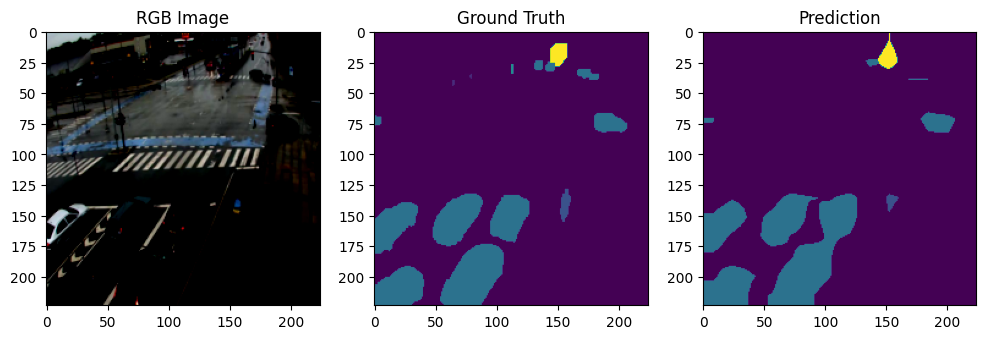

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79607844..0.9843137].


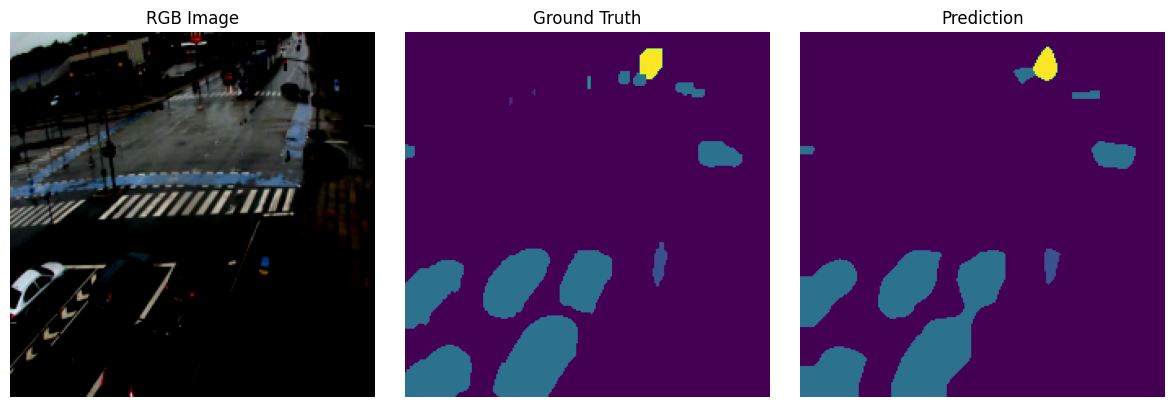

In [46]:
visualize_sample(test_dataset[150], model)

visualize_sample2(test_dataset[150], model2)